In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
def f(x):
    return 3*x**2 - 4*x +5

In [5]:
f(3.0)


20.0

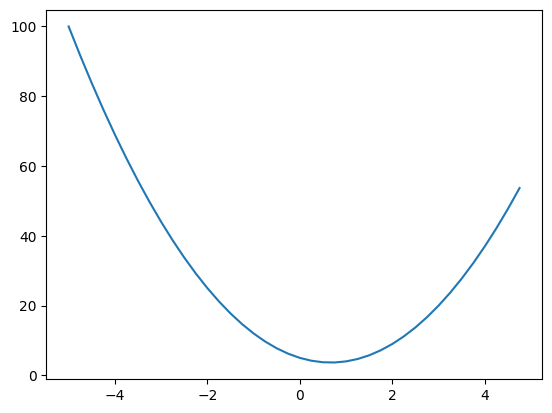

In [6]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [7]:
h = 0.00000000001
x = 3.0
(f(x+h)-f(x))/h

14.000178794049134

In [8]:
a = 2.0
b = -3.0
c = 10.0
d = a*b +c
d

4.0

In [9]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0
d1 = a*b +c
a +=h
d2 = a*b+c

print("d1",d1)
print("d2",d2)
print("slope",(d2-d1)/h)
      


d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [10]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __pow__(self,other):
        assert isinstance(other, (int,float)), "only supporting int/float powers for now"
        out = Value(self.data**other,(self,),f'**{other}')

        def _backward():
            self.grad += other * self.data**(other-1)*out.grad

        out._backward = _backward
        return out

    def __rmul__(self,other): #other*self
        return self*other

    def __truediv__(self,other): # self / other
        return self*other**-1

    def __neg__(self): #-self
        return self*-1

    def __sub__(self,other): # self - other
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,),'exp')

        def _backward():
            self.grad = out.data*out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [11]:
a = Value(2.0)
b = Value (4.0)
a-b

Value(data=-2.0)

In [12]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format = "svg", graph_attr={'rankdir':'LR'})#LR = left to right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any value in the graph, create a reactanaglur ('record') node for it
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape = 'record')
        if n._op:
            #if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op , label = n._op)
            #and connect this node to it
            dot.edge(uid + n._op,uid)

    for n1,n2 in edges:
        #connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2)) + n2._op)

    return dot

In [13]:
#inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#bias of the neuron
b = Value(6.8813735870195432, label = 'b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

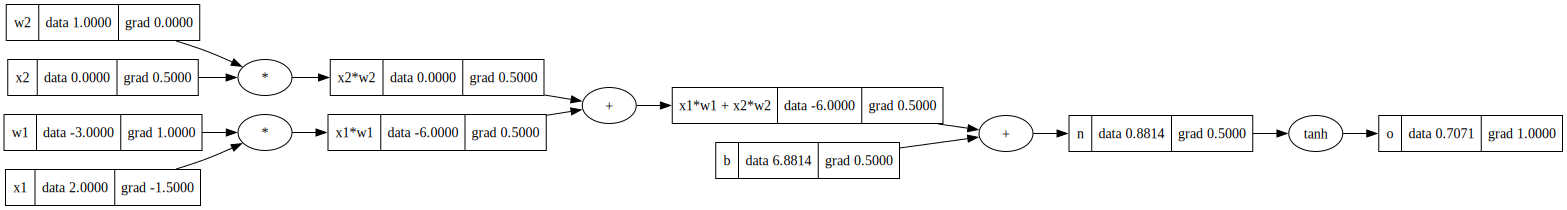

In [14]:
draw_dot(o)

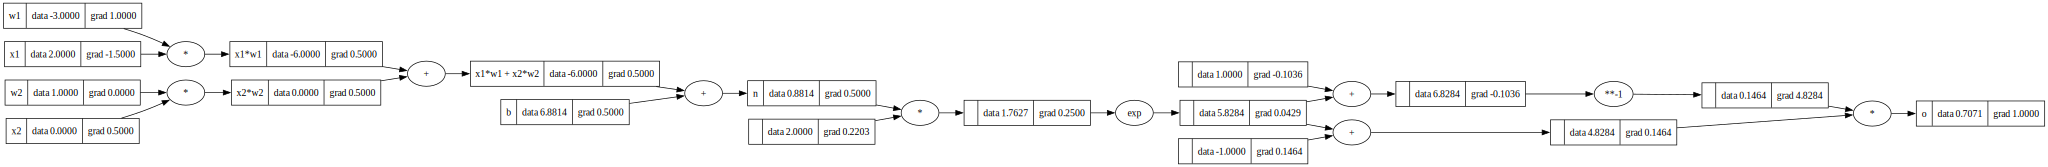

In [15]:
#inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#bias of the neuron
b = Value(6.8813735870195432, label = 'b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#---
e = (2*n).exp()
o = (e -1)/(e+1)
#---
o.label = 'o'
o.backward()
draw_dot(o)

In [16]:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()
print('---')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [101]:
import random
class Neuron:

    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        # w * x +b
       act = sum((wi*xi for wi, xi in zip(self.w,x)),self.b)
       out = act.tanh()
       return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:

    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=-0.09138896616642717)

In [28]:
n.parameters()

[Value(data=-0.8075980758591561),
 Value(data=0.9941533226901726),
 Value(data=-0.5976796787970029),
 Value(data=-0.4223099603608309),
 Value(data=0.049781695405898496),
 Value(data=-0.6665062946479627),
 Value(data=-0.3219534727104705),
 Value(data=-0.2529570710723177),
 Value(data=-0.6062880324469648),
 Value(data=-0.5615245174581129),
 Value(data=-0.5546595801113563),
 Value(data=-0.12654964869541852),
 Value(data=-0.7895421995882039),
 Value(data=0.6142888455545219),
 Value(data=0.9250614965572148),
 Value(data=-0.950075585431114),
 Value(data=0.5272773213289388),
 Value(data=-0.1440693693447619),
 Value(data=0.4290820806867932),
 Value(data=-0.7115867223197874),
 Value(data=-0.527296409281097),
 Value(data=-0.47543846944756774),
 Value(data=0.5838038108809003),
 Value(data=0.8814920575064045),
 Value(data=-0.28839183296425075),
 Value(data=-0.13012893899532707),
 Value(data=-0.5596888503832667),
 Value(data=-0.9833518435115118),
 Value(data=0.40172227941425653),
 Value(data=-0.963

In [102]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],]

ys = [1.0,-1.0,-1.0,1.0] # desired targets

In [111]:
for k in range(20):

    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys,ypred))

    #backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.1 * p.grad

    print(k,loss.data)
    

0 0.01088275296387191
1 0.010641228813966487
2 0.010409981147659684
3 0.01018836808363576
4 0.00997580015678403
5 0.00977173506979823
6 0.009575673063538334
7 0.009387152822627176
8 0.009205747845403433
9 0.009031063217888468
10 0.008862732740226597
11 0.008700416361443926
12 0.008543797884584118
13 0.008392582909526675
14 0.008246496985237366
15 0.008105283946975694
16 0.007968704417201714
17 0.007836534451672305
18 0.0077085643145730276
19 0.0075845973685540755


In [108]:
ypred

[Value(data=0.9258642229089249),
 Value(data=-0.9049357554653708),
 Value(data=-0.9805111867756681),
 Value(data=0.9283047074592116)]